# Stage 2: Optimization

**Goal of this step:** We feed the 200*8 segmented demand matrix built in the previous notebook into the optimizer. The optimization model itself is unchanged from Stage 1 (only its input differs). The solver decides which sites to open, in what format, and which clients to assign where, maximizing total captured weekly demand within the 850 k euros budget.

>Note: Functions are in `handlers/optimization_handlers.py`. The solver is `opticlean_optimization.py` at the project root.

In [1]:
import sys
sys.path.append('handlers')
import matplotlib.pyplot as plt
import handlers.optimization_handlers as oh

demand_matrix, potential, sites = oh.load_inputs()
print(f"Demand matrix : {demand_matrix.shape}")
print(f"Non zero entries : {(demand_matrix > 0).sum()} / {demand_matrix.size}")

Demand matrix : (200, 8)
Non zero entries : 1252 / 1600


## 1. Run the optimizer

We pass the segmented demand matrix and the candidate sites data to `solve_location_model()`. The solver handles site selection, format choice and client assignment all at once.

In [2]:
result = oh.run_optimization(demand_matrix, sites, budget=850, verbose=True)

Restricted license - for non-production use only - expires 2027-11-29
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 26.04 LTS")

CPU model: Intel(R) Core(TM) Ultra 7 258V, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1817 rows, 1616 columns and 7700 nonzeros (Max)
Model fingerprint: 0xb955614b
Model has 1252 linear objective coefficients
Variable types: 0 continuous, 1616 integer (1616 binary)
Coefficient statistics:
  Matrix range     [1e-01, 5e+03]
  Objective range  [1e-01, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+02]

Found heuristic solution: objective -0.0000000
Presolve removed 364 rows and 348 columns
Presolve time: 0.01s
Presolved: 1453 rows, 1268 columns, 6303 nonzeros
Variable types: 0 continuous, 1268 integer (1268 binary)

Root relaxation: objective 1.324203e+04, 205 iterations, 0.01 seconds (0.01 work

## 2. Results

In [3]:
oh.print_summary(result)

Total captured demand : 13120.5 units/week
Budget used           : 806 / 850 k€
Clients assigned      : 189 / 200
Clients unassigned    : 11

 site_id format  capacity  cost  used_capacity  capacity_utilization
       0  small    2500.0 144.0    1912.345534              0.764938
       1  small    2800.0 158.0    2798.090701              0.999318
       4  small    2500.0 144.0    2284.850098              0.913940
       6  large    4200.0 207.0    3543.902597              0.843786
       7  small    2700.0 153.0    2581.291395              0.956034


## 3. Visualizations

The map shows each potential client colored by the store they are assigned to. Square markers are large format stores, triangles are small format, and crosses are sites that were not opened.

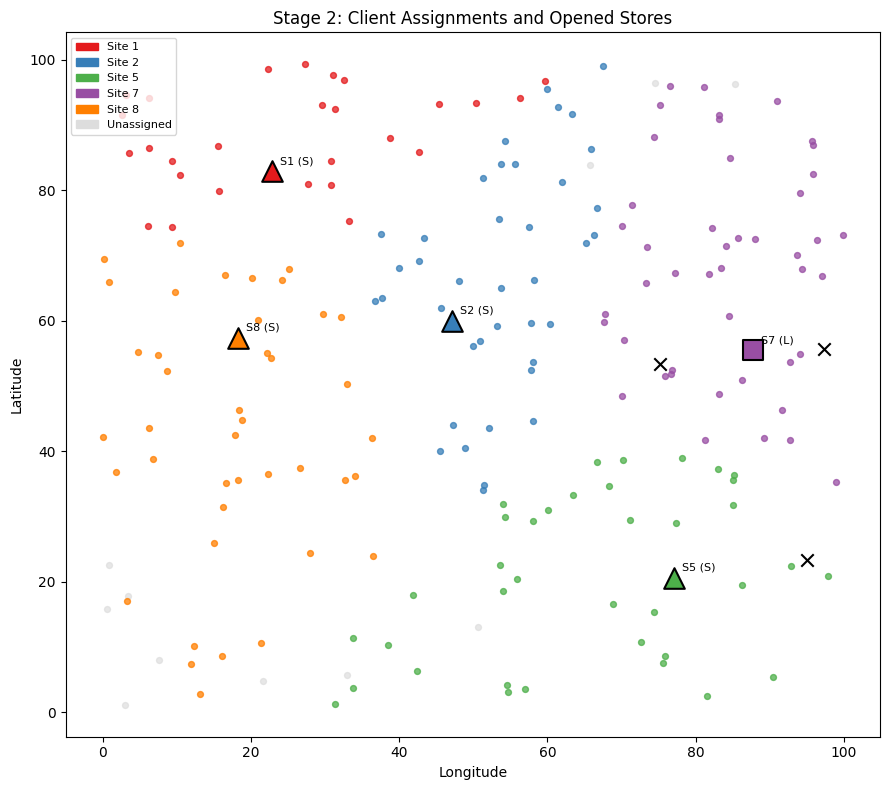

In [4]:
oh.plot_assignment_map(result, potential, sites)
plt.show()

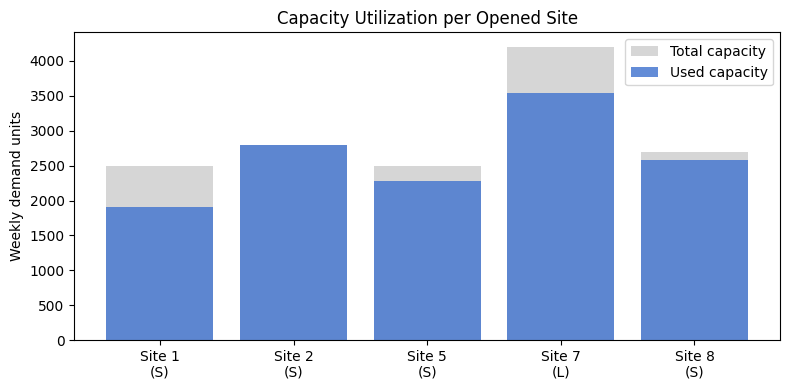

In [5]:
oh.plot_capacity_utilization(result)
plt.show()